# Flower Image Classifier with TensorFlow and Transfer Learning

This project trains a deep learning model that recognizes **102 species of flowers** from a photo. It uses transfer learning on **MobileNetV2** (loaded from TensorFlow Hub) and the [Oxford Flowers 102](https://www.robots.ox.ac.uk/~vgg/data/flowers/102/) dataset. The trained model is exported as a Keras file and served by a command-line app (`predict/predict.py`) that returns the top-K most likely species for any image.

Steps:

1. Load the dataset with TensorFlow Datasets and build `tf.data` input pipelines.
2. Train a classification head on top of a frozen MobileNetV2 feature extractor.
3. Evaluate on the held-out test set (images never seen during training or validation).
4. Save the model and run inference on new images.

Originally built in 2020 for Udacity's *Intro to Machine Learning with TensorFlow* Nanodegree. Updated in 2026 to run on current TensorFlow (local, Colab Enterprise or Vertex AI Workbench), to report accuracy on the test set and to reduce overfitting.

## Setup

The TensorFlow Hub layer needs the Keras 2 API (`tf-keras`) on TensorFlow 2.16 and later. Run this cell first; if TensorFlow was already imported in this session, restart the runtime after it.

In [1]:
import importlib.metadata as md
import os

tf_minor = ".".join(md.version("tensorflow").split(".")[:2])
%pip install -q "tf-keras~={tf_minor}.0" tensorflow-hub tensorflow-datasets importlib_resources scipy "setuptools<81"

os.environ["TF_USE_LEGACY_KERAS"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import tensorflow_hub as hub
from PIL import Image

warnings.filterwarnings("ignore")
tfds.disable_progress_bar()
tf.get_logger().setLevel("ERROR")
%config InlineBackend.figure_format = 'retina'

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU") or "not found, running on CPU")

TensorFlow: 2.21.0
GPU: not found, running on CPU


/private/tmp/claude-501/-Users-albert-Documents-dev-wixu/596c1537-276b-41ac-bfdc-30696c5447d4/scratchpad/ic/.venv/lib/python3.12/site-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


The label map and the sample images live in the `predict/` folder of the repository. On a fresh Colab runtime, set `REPO_URL` and the cell clones the repository.

In [3]:
REPO_URL = "https://github.com/scyanh/image_classifier_tensorflow"
DATA_DIR = "predict"

if not os.path.exists(os.path.join(DATA_DIR, "label_map.json")):
    !git clone -q {REPO_URL} repo
    DATA_DIR = os.path.join("repo", "predict")

MODEL_PATH = os.path.join(DATA_DIR, "fmodel.h5")

## Load the dataset

Oxford Flowers 102 has three splits. In TensorFlow Datasets the `train` and `validation` splits are small (1,020 images each, 10 per class) and `test` is large (6,149 images).

In [4]:
dataset, dataset_info = tfds.load("oxford_flowers102", as_supervised=True, with_info=True)

training_set = dataset["train"]
validation_set = dataset["validation"]
test_set = dataset["test"]

num_classes = dataset_info.features["label"].num_classes
for split in ("train", "validation", "test"):
    print(f"{split:>10}: {dataset_info.splits[split].num_examples:,} images")
print(f"   classes: {num_classes}")

     train: 1,020 images
validation: 1,020 images
      test: 6,149 images
   classes: 102


## Label mapping

`label_map.json` maps class ids to flower names. Its keys go from 1 to 102 while the dataset labels go from 0 to 101, so every lookup adds 1.

In [5]:
with open(os.path.join(DATA_DIR, "label_map.json")) as f:
    class_names = json.load(f)

def label_name(label):
    return class_names[str(int(label) + 1)].title()

for image, label in training_set.take(3):
    print(f"label {label.numpy():>3} ({label_name(label)}), shape {image.shape}")

label  72 (Water Lily), shape (500, 667, 3)
label  84 (Desert-Rose), shape (500, 666, 3)
label  70 (Gazania), shape (670, 500, 3)


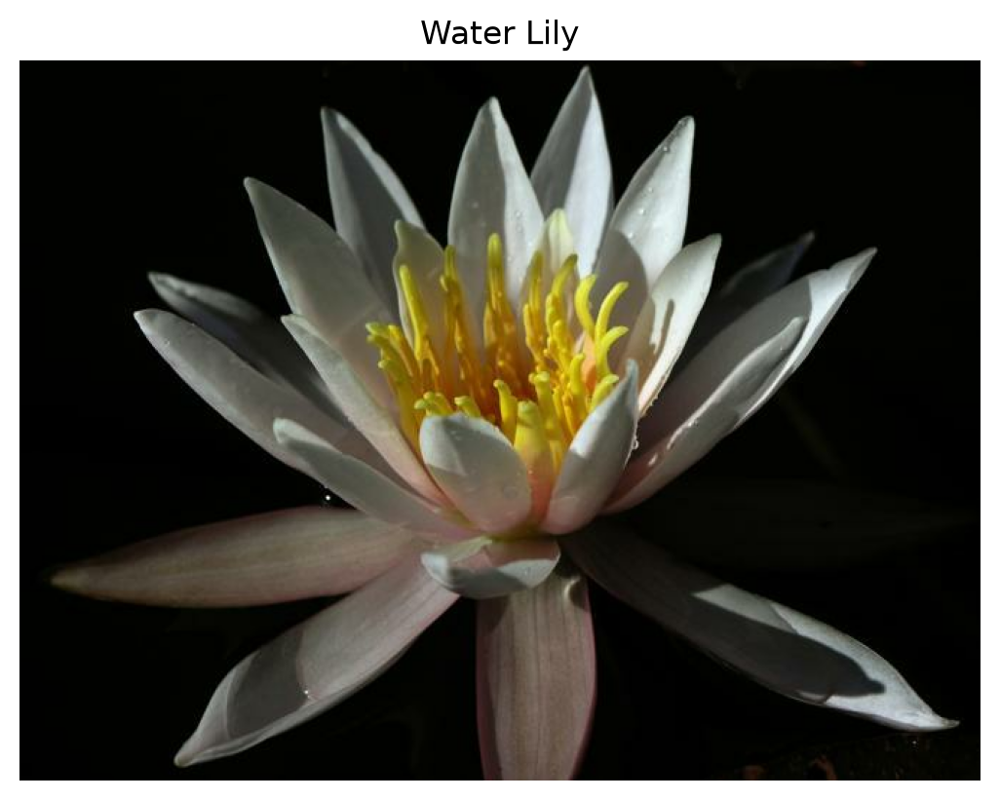

In [6]:
for image, label in training_set.take(1):
    plt.imshow(image.numpy())
    plt.title(label_name(label))
    plt.axis("off")
    plt.show()

## Input pipelines

Every image is resized to 224×224 and scaled to [0, 1], the input format MobileNetV2 expects. The small training and validation splits are cached in memory after resizing.

In [7]:
IMAGE_SIZE = 224
BATCH_SIZE = 32

def normalize(image, label):
    image = tf.image.resize(tf.cast(image, tf.float32), (IMAGE_SIZE, IMAGE_SIZE)) / 255.0
    return image, label

num_training_examples = dataset_info.splits["train"].num_examples
training_batches = (training_set.map(normalize).cache()
                    .shuffle(num_training_examples).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))
validation_batches = validation_set.map(normalize).cache().batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
testing_batches = test_set.map(normalize).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

## Build the model

MobileNetV2, pre-trained on ImageNet, is used as a frozen feature extractor that turns each image into a 1,280-dimensional embedding. Only the new classification head is trained: dropout for regularization and a 102-way softmax layer.

In [8]:
MOBILENET_URL = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"

feature_extractor = hub.KerasLayer(MOBILENET_URL, input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), trainable=False)

model = tf.keras.Sequential([
    feature_extractor,
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(num_classes, activation="softmax"),
])
model.summary()

Model: "sequential"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 keras_layer (KerasLayer)    (None, 1280)              2257984   


 dropout (Dropout)           (None, 1280)              0         


 dense (Dense)               (None, 102)               130662    


Total params: 2388646 (9.11 MB)


Trainable params: 130662 (510.40 KB)


Non-trainable params: 2257984 (8.61 MB)


_________________________________________________________________


## Train

Adam with sparse categorical cross-entropy. Early stopping watches the validation loss and restores the best weights, so the model stops before it memorizes the 1,020 training images.

In [9]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
history = model.fit(training_batches, epochs=30, validation_data=validation_batches,
                    callbacks=[early_stopping], verbose=2)

Epoch 1/30


32/32 - 4s - loss: 4.4299 - accuracy: 0.0784 - val_loss: 3.1556 - val_accuracy: 0.3725 - 4s/epoch - 110ms/step


Epoch 2/30


32/32 - 2s - loss: 2.2799 - accuracy: 0.5794 - val_loss: 2.0970 - val_accuracy: 0.6216 - 2s/epoch - 73ms/step


Epoch 3/30


...

32/32 - 2s - loss: 0.0254 - accuracy: 1.0000 - val_loss: 0.7298 - val_accuracy: 0.8275 - 2s/epoch - 75ms/step


Epoch 29/30


32/32 - 2s - loss: 0.0231 - accuracy: 1.0000 - val_loss: 0.7258 - val_accuracy: 0.8255 - 2s/epoch - 76ms/step


Epoch 30/30


32/32 - 2s - loss: 0.0233 - accuracy: 1.0000 - val_loss: 0.7207 - val_accuracy: 0.8265 - 2s/epoch - 76ms/step


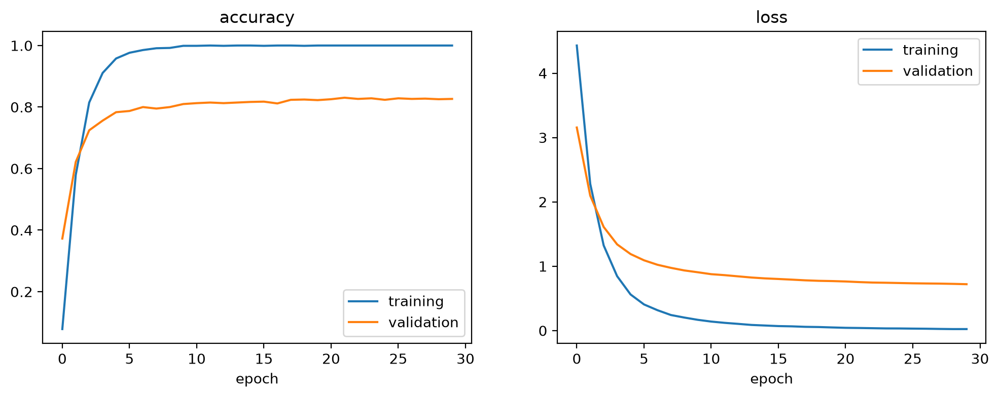

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric in ((ax1, "accuracy"), (ax2, "loss")):
    ax.plot(history.history[metric], label="training")
    ax.plot(history.history[f"val_{metric}"], label="validation")
    ax.set_title(metric)
    ax.set_xlabel("epoch")
    ax.legend()
plt.show()

## Evaluate on the test set

The test split is never used for training or model selection, so its accuracy is the honest estimate of how the model performs on new photos.

In [11]:
test_loss, test_accuracy = model.evaluate(testing_batches, verbose=0)
print(f"Test accuracy: {test_accuracy:.1%}")
print(f"Test loss:     {test_loss:.3f}")

Test accuracy: 78.7%
Test loss:     0.857


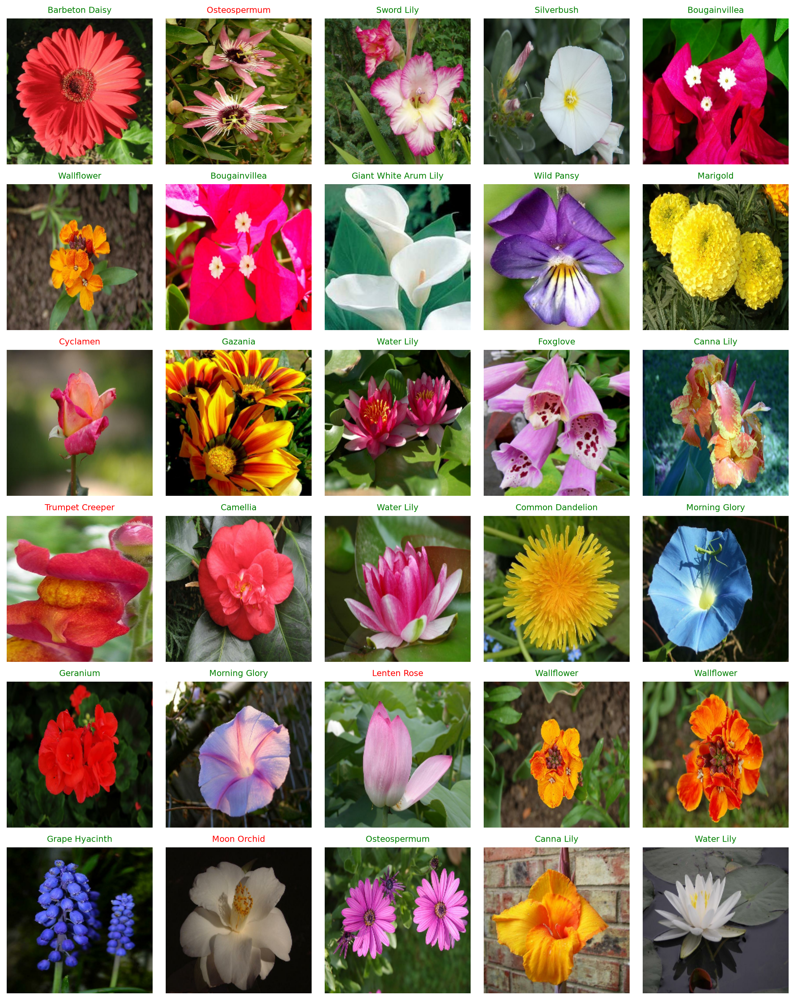

In [12]:
for image_batch, label_batch in testing_batches.take(1):
    probabilities = model.predict(image_batch, verbose=0)

plt.figure(figsize=(12, 15))
for n in range(30):
    predicted = np.argmax(probabilities[n])
    plt.subplot(6, 5, n + 1)
    plt.imshow(image_batch[n].numpy())
    plt.title(label_name(predicted), color="green" if predicted == label_batch[n] else "red", fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

## Save and reload the model

The model is saved as a Keras HDF5 file, the format the command-line app loads. Reloading it and comparing predictions confirms the export is complete.

In [13]:
model.save(MODEL_PATH)

reloaded_model = tf.keras.models.load_model(MODEL_PATH, custom_objects={"KerasLayer": hub.KerasLayer})
same = np.allclose(model.predict(image_batch, verbose=0), reloaded_model.predict(image_batch, verbose=0), atol=1e-5)
print(f"Saved to {MODEL_PATH} ({os.path.getsize(MODEL_PATH) / 1e6:.1f} MB); reloaded predictions match: {same}")

Saved to predict/fmodel.h5 (10.9 MB); reloaded predictions match: True


## Inference

`process_image` resizes a photo to 224×224 and scales its pixels to [0, 1]. `predict` returns the top-K probabilities and their class ids. The command-line app in `predict/predict.py` uses the same steps.

In [14]:
def process_image(image):
    image = tf.image.resize(tf.convert_to_tensor(image, dtype=tf.float32), (IMAGE_SIZE, IMAGE_SIZE)) / 255.0
    return image.numpy()

def predict(image_path, model, top_k=5):
    image = process_image(np.asarray(Image.open(image_path).convert("RGB")))
    probabilities = model.predict(np.expand_dims(image, 0), verbose=0)[0]
    top = np.argsort(probabilities)[::-1][:top_k]
    return probabilities[top], [str(i + 1) for i in top]

probs, classes = predict(os.path.join(DATA_DIR, "test_images", "orange_dahlia.jpg"), reloaded_model)
print(probs.round(4))
print(classes)

[0.5067 0.2318 0.0488 0.0409 0.0348]
['59', '5', '66', '100', '71']


## Sanity check on new images

Four photos outside the dataset, each shown with the model's top 5 predictions.

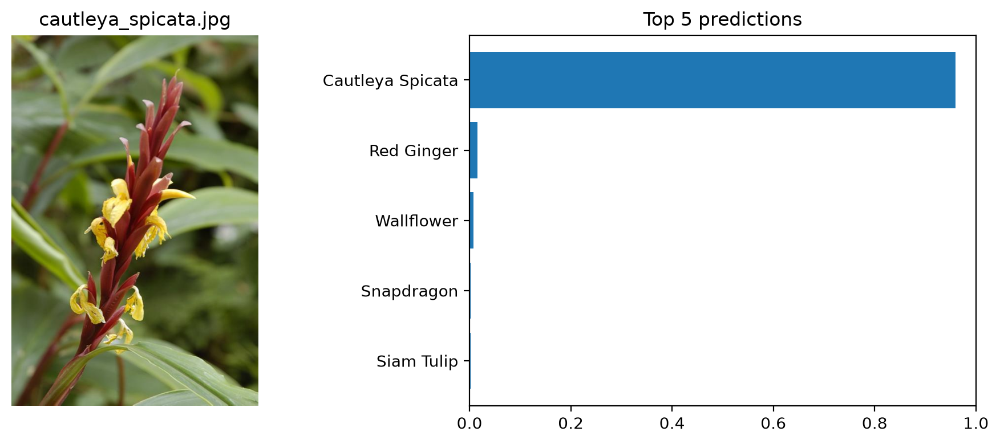

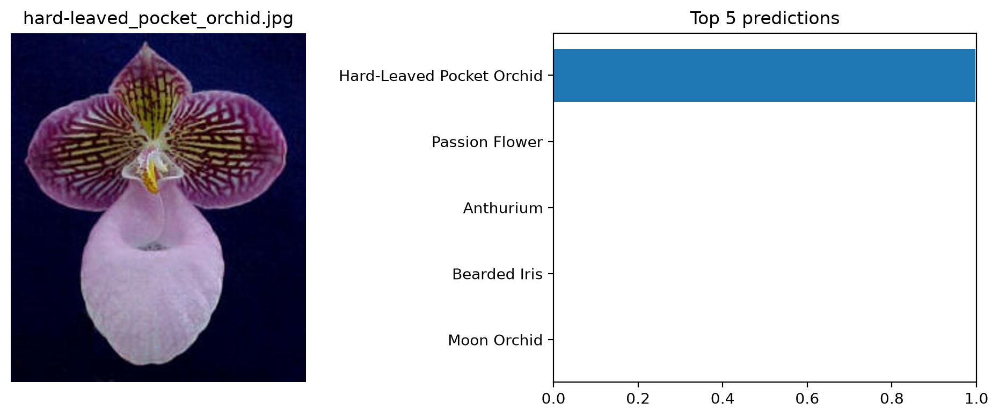

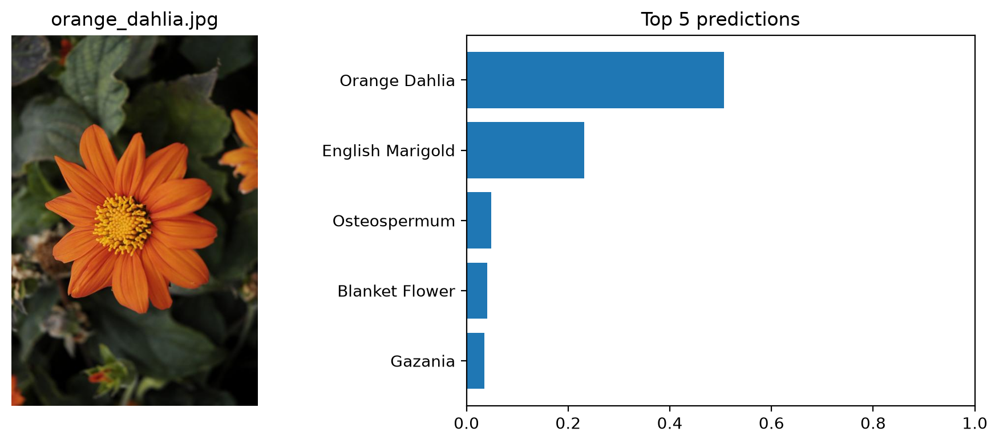

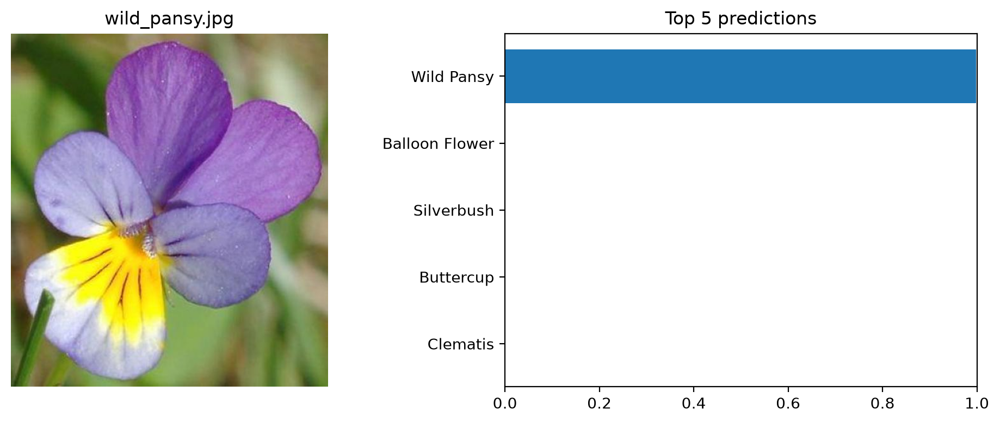

In [15]:
test_images = ["cautleya_spicata.jpg", "hard-leaved_pocket_orchid.jpg", "orange_dahlia.jpg", "wild_pansy.jpg"]

for file_name in test_images:
    path = os.path.join(DATA_DIR, "test_images", file_name)
    probs, classes = predict(path, reloaded_model)
    names = [class_names[c].title() for c in classes]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.imshow(Image.open(path))
    ax1.set_title(file_name)
    ax1.axis("off")
    ax2.barh(names[::-1], probs[::-1])
    ax2.set_xlim(0, 1)
    ax2.set_title("Top 5 predictions")
    plt.tight_layout()
    plt.show()

## Command-line app

```bash
cd predict
TF_USE_LEGACY_KERAS=1 python predict.py test_images/orange_dahlia.jpg fmodel.h5 --top_k 5 --category_names label_map.json
```